In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
#PARTS 1 & 2

In [ ]:
#PART 1

In [3]:
file = "/content/gdrive/MyDrive/final_project/data/project_option_parity_TSLA_20260818.xlsx"

In [4]:
#SECTION 1.1

EXPIRATIONS = [
    "2026-09-18",
    "2026-10-16",
    "2026-11-20",
    "2026-12-18",
    "2027-01-15",
]

spot_df = pd.read_excel(file, sheet_name="spot")

S0 = float(spot_df.loc[spot_df["field"] == "price", "value"].iloc[0])

print(f"TSLA spot price = ${S0:.2f}")

data = {}

for sheet in EXPIRATIONS:
  df = pd.read_excel(file, sheet_name=sheet)

  # Bid-ask spread
  df["spread"] = df["ask"] - df["bid"]

  # Midpoint
  df["mid"] = (df["bid"] + df["ask"]) / 2

  # Relative spread
  df["relative_spread"] = (df["spread"] / df["mid"])

  # Moneyness
  df["moneyness"] = (df["strike"] / S0)

  data[sheet] = df

#Auditing 5 expirations

audit_rows = []

for sheet, df in data.items():
  calls = df[df["option type"] == "Call"]

  puts = df[df["option type"] == "Put"]

  call_strikes = set(calls["strike"])

  put_strikes = set(puts["strike"])

  matched_strikes = (call_strikes & put_strikes)

  audit_rows.append({
      "expiration": sheet,

      "days_to_expiration":int(df["days to expiration"].iloc[0]),

      "call_quotes":len(calls),

      "put_quotes":len(puts),

      "matched_strikes":len(matched_strikes),

      "min_strike":df["strike"].min(),

      "max_strike":df["strike"].max(),

      # Calls
      "call_avg_spread":calls["spread"].mean(),

      "call_median_spread":calls["spread"].median(),

      "call_avg_relative_spread":calls["relative_spread"].mean(),

      # Puts
      "put_avg_spread":puts["spread"].mean(),

      "put_median_spread":puts["spread"].median(),

      "put_avg_relative_spread":puts["relative_spread"].mean(),

      # Volume
      "call_mean_volume":calls["volume"].mean(),

      "call_median_volume":calls["volume"].median(),

      "call_total_volume":calls["volume"].sum(),

      "put_mean_volume":puts["volume"].mean(),

      "put_median_volume":puts["volume"].median(),

      "put_total_volume":puts["volume"].sum(),

      # Open interest
      "call_mean_OI":calls["open interest"].mean(),

      "call_median_OI":calls["open interest"].median(),

      "call_total_OI":calls["open interest"].sum(),

      "put_mean_OI":puts["open interest"].mean(),

      "put_median_OI":puts["open interest"].median(),

      "put_total_OI":puts["open interest"].sum(),})


audit = pd.DataFrame(audit_rows)

print("\n==============================")
print("SECTION 1.1")
print("==============================")

print(audit.round(3).to_string(index=False))

TSLA spot price = $339.30

SECTION 1.1
expiration  days_to_expiration  call_quotes  put_quotes  matched_strikes  min_strike  max_strike  call_avg_spread  call_median_spread  call_avg_relative_spread  put_avg_spread  put_median_spread  put_avg_relative_spread  call_mean_volume  call_median_volume  call_total_volume  put_mean_volume  put_median_volume  put_total_volume  call_mean_OI  call_median_OI  call_total_OI  put_mean_OI  put_median_OI  put_total_OI
2026-09-18                  31           41          41               41         240         440            1.104               0.350                     0.032           1.010               0.20                    0.043           505.659               198.0              20732          337.098               75.0             13821      3556.732          3020.0         145826     5429.244         3127.0        222599
2026-10-16                  59           41          41               41         240         440            1.120            

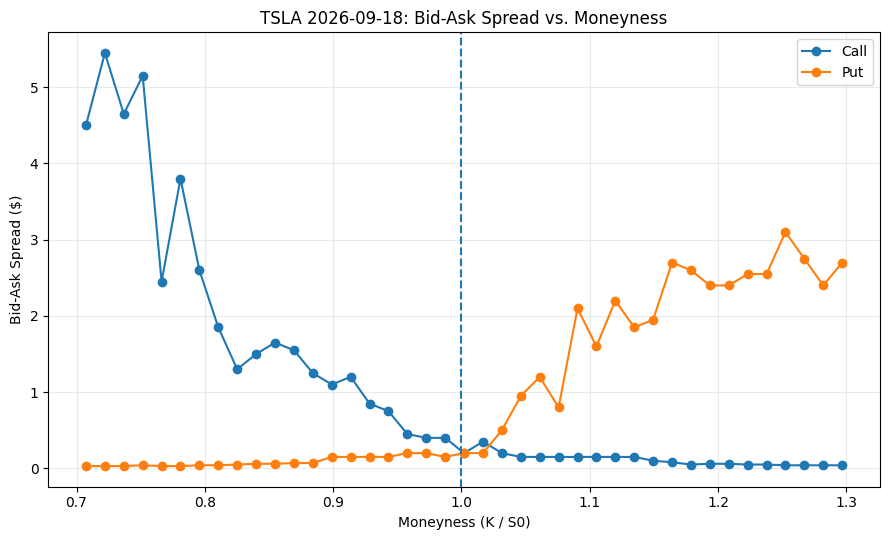

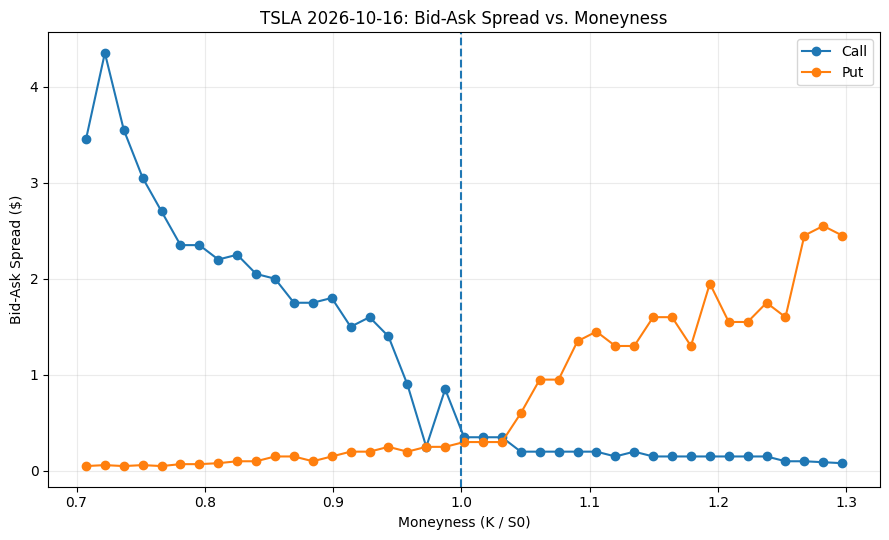

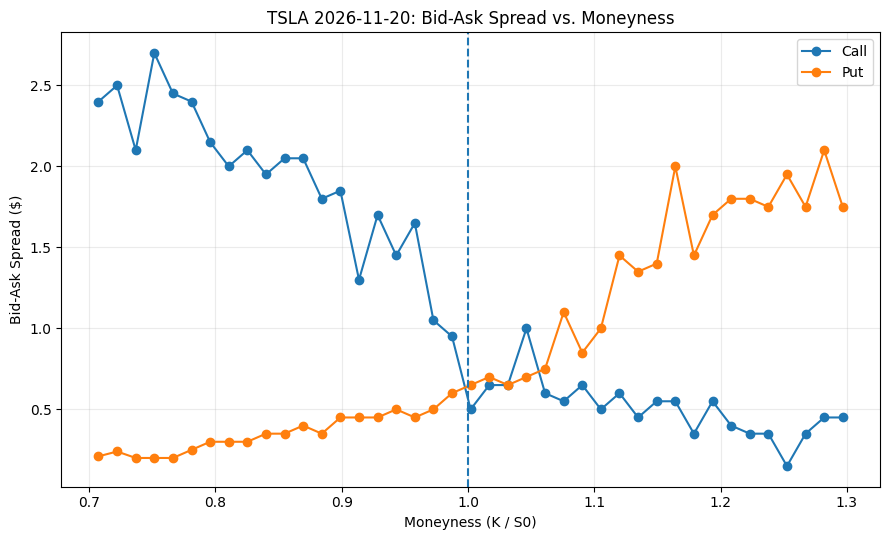

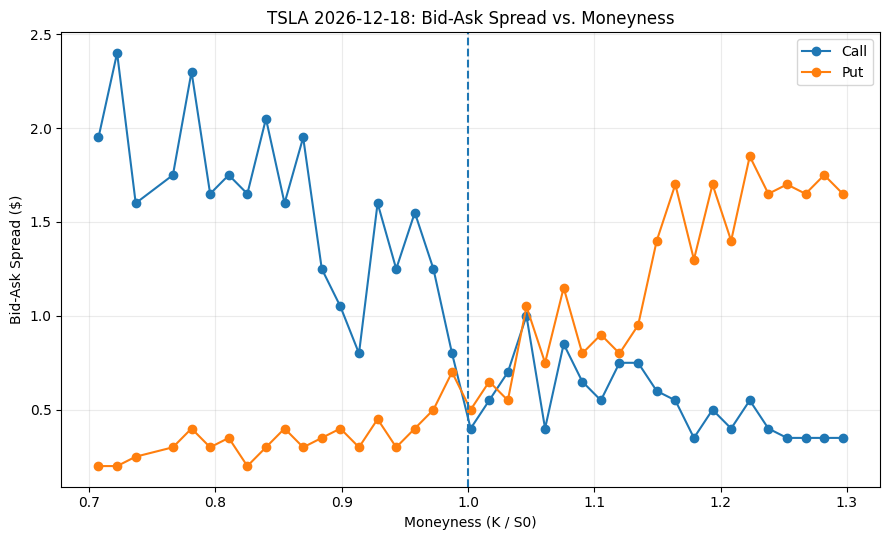

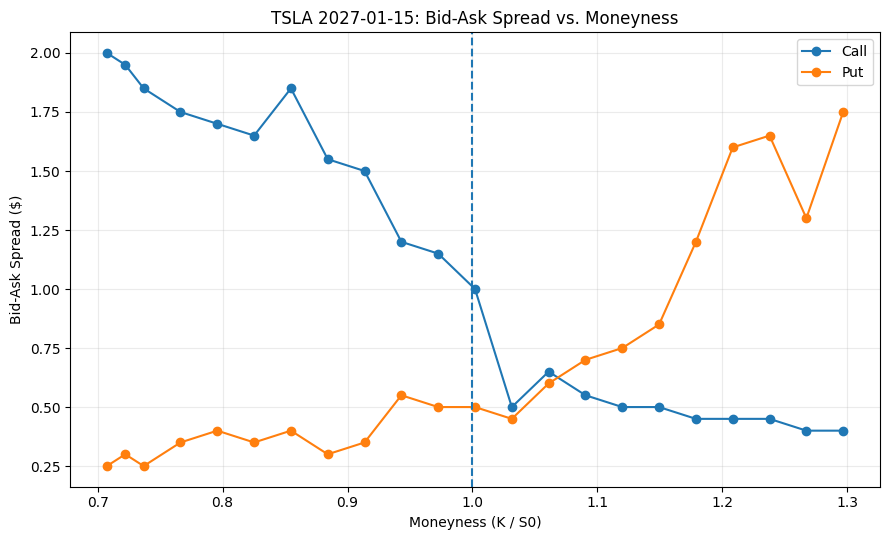

In [5]:
# SECTION 1.2

for sheet, df in data.items():
    calls = (df[df["option type"] == "Call"].sort_values("moneyness"))

    puts = (df[df["option type"] == "Put"
      ].sort_values("moneyness"))

    plt.figure(figsize=(9, 5.5))

    plt.plot(
      calls["moneyness"],
      calls["spread"],
      marker="o",
      label="Call"
  )

    plt.plot(
        puts["moneyness"],
        puts["spread"],
        marker="o",
        label="Put"
    )

    # ATM line
    plt.axvline(
        1.0,
        linestyle="--"
    )

    plt.title(f"TSLA {sheet}: "
        "Bid-Ask Spread vs. Moneyness")

    plt.xlabel("Moneyness (K / S0)")

    plt.ylabel("Bid-Ask Spread ($)")

    plt.grid(True,alpha=0.25)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [7]:
# SECTION 2.1

selected_expirations = [
    "2026-10-16",
    "2026-12-18"]

#defining an unchanged qlty filter

MAX_SPREAD = 2.00

MIN_OPEN_INTEREST = 100

MIN_VOLUME = 5

MIN_MONEYNESS = 0.80

MAX_MONEYNESS = 1.20


def quality_filter(df):
  filtered = df[(df["bid"] > 0)
      &
      (df["ask"] > df["bid"])
      &
      (df["spread"] <= MAX_SPREAD)
      &
      (df["open interest"]
          >= MIN_OPEN_INTEREST)
      &
      (df["volume"]
          >= MIN_VOLUME)
      &
      (df["moneyness"].between(MIN_MONEYNESS, MAX_MONEYNESS))].copy()
  return filtered

#Test filter

filter_results = []

for sheet in selected_expirations:
  df = data[sheet]

  #Pre-filtering

  calls_before = df[df["option type"] == "Call"]
  puts_before = df[df["option type"] == "Put"]

  matched_before = (set(calls_before["strike"])
      & set(puts_before["strike"]))
  #same filter
  filtered = quality_filter(df)

  calls_after = filtered[filtered["option type"] == "Call"]

  puts_after = filtered[filtered["option type"] == "Put"]

  #Matched after filtering
  matched_after = (set(calls_after["strike"]) & set(puts_after["strike"]))

  filter_results.append({

      "expiration": sheet,

      "DTE":int(df["days to expiration"].iloc[0]),

      "before_calls":len(calls_before),

      "before_puts":len(puts_before),

      "before_matched":len(matched_before),

      "after_calls":len(calls_after),

      "after_puts":len(puts_after),

      "after_matched":len(matched_after)})


filter_results = pd.DataFrame(filter_results)

print("SECTION 2.1")
print("==============================")

print(filter_results.to_string(
        index=False))

# Make sure the assignment requirement is met

if (filter_results["after_matched"]
    < 8).any():

  raise ValueError("Filter failed: fewer than 8 matched strikes.")

SECTION 2.1
expiration  DTE  before_calls  before_puts  before_matched  after_calls  after_puts  after_matched
2026-10-16   59            41           41              41           23          24             20
2026-12-18  122            40           40              40           23          21             17


In [8]:
# SECTION 2.2

def create_matched_table(df):
    filtered = quality_filter(
        df)

    calls = (filtered[filtered["option type"] == "Call"].set_index("strike"))

    puts = (filtered[filtered["option type"] == "Put"].set_index("strike"))

    common_strikes = sorted(set(calls.index)
        & set(puts.index))

    rows = []

    for strike in common_strikes:
        call = calls.loc[strike]
        put = puts.loc[strike]

        rows.append({
            "strike":strike,

            "moneyness":strike / S0,

            # Call

            "call_bid":call["bid"],

            "call_ask":call["ask"],

            "call_spread":call["spread"],

            "call_volume":call["volume"],

            "call_open_interest":call["open interest"],

            # Put

            "put_bid":put["bid"],

            "put_ask":put["ask"],

            "put_spread":put["spread"],

            "put_volume":put["volume"],

            "put_open_interest":put["open interest"]})

    return pd.DataFrame(rows)


# ============================================================
# PRINT FIRST 4 + LAST 4 CALLS/PUTS
# ============================================================

for sheet in selected_expirations:

    matched = create_matched_table(
        data[sheet]
    )

    print("\n==============================")
    print(f"SECTION 2.2: {sheet}")
    print("==============================")

    print(f"Total retained matched "
        f"strikes = {len(matched)}")

    first_four = matched.head(4)

    last_four = matched.tail(4)

    display_table = pd.concat(
        [first_four,
            last_four
        ]).drop_duplicates(
        subset=["strike"])

    print(display_table.round(4)
        .to_string(index=False))


SECTION 2.2: 2026-10-16
Total retained matched strikes = 20
 strike  moneyness  call_bid  call_ask  call_spread  call_volume  call_open_interest  put_bid  put_ask  put_spread  put_volume  put_open_interest
    290     0.8547     55.25     57.25         2.00            5                 157     4.55     4.70        0.15         141               3193
    300     0.8842     47.35     49.10         1.75           47                 537     6.55     6.65        0.10         670               7509
    305     0.8989     43.55     45.35         1.80           41                 545     7.70     7.85        0.15          18               2703
    310     0.9136     40.15     41.65         1.50           25                2044     9.05     9.25        0.20          73               3303
    375     1.1052     10.70     10.90         0.20          139                2158    43.45    44.90        1.45           6                735
    380     1.1200      9.60      9.75         0.15          83